In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import os
import sys
import warnings

# 1. THE OS-LEVEL BLOCK (The most important for n_jobs=-1)
# This tells the Operating System to kill all warnings before Python even starts sub-processes
os.environ['PYTHONWARNINGS'] = 'ignore'

# 2. THE PYTHON-LEVEL BLOCK
# Catch everything from basic warnings to specific ConvergenceWarnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.simplefilter("ignore")

# 3. THE "DEEP SILENCE" HACK
# Some libraries print directly to the system's 'stderr' (the red box)
# This redirects that output to a void so it never reaches your screen.
class DevNull:
    def write(self, msg): pass
    def flush(self): pass
        
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.cross_decomposition import PLSRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.model_selection import LeaveOneOut, cross_val_predict, learning_curve
from sklearn.metrics import (
    r2_score, 
    mean_absolute_error, 
    mean_squared_error, 
    mean_absolute_percentage_error
)
import shutil
import joblib
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sanilawijesekara/yield-dataset-combined/yield_final.csv


In [2]:
work_dir = "/kaggle/working"

for filename in os.listdir(work_dir):
    file_path = os.path.join(work_dir, filename)
    if os.path.isfile(file_path) or os.path.islink(file_path):
        os.unlink(file_path)
    elif os.path.isdir(file_path):
        shutil.rmtree(file_path)

print("Output directory cleaned!")

Output directory cleaned!


In [3]:
df_final = pd.read_csv("/kaggle/input/datasets/sanilawijesekara/yield-dataset-combined/yield_final.csv")
df_final.head()

,Unnamed: 0,district,year,pixel_id,veg_days,repro_days,peak_health,auc_health,avg_health,temp_flowering,...,PC4,PC5,District,Year,Season,Average_yield_kg_per_ha,Harvested_extent_ha,Total_production_MT,Season_ID,District_ID
0,0,Ampara,2022,1621.251272,106.539232,54.752582,0.901939,6.842034,-0.021292,-0.847574,...,-1.828828,0.825333,Ampara,2022,Maha,2857,77631,221529,0,0
1,1,Ampara,2022,1607.637649,64.594595,50.125707,0.945928,4.352596,-0.039154,0.235582,...,-0.908302,1.030039,Ampara,2022,Yala,3708,59869,221999,1,0
2,2,Ampara,2023,1623.185289,222.591554,124.489637,1.381839,14.947866,-0.006680,-0.897823,...,-0.527367,-0.128902,Ampara,2023,Maha,4172,76347,318517,0,0
3,3,Ampara,2023,1622.000000,133.217257,82.779661,1.332580,9.916422,0.024450,1.125715,...,-0.719562,0.079124,Ampara,2023,Yala,4338,60377,261938,1,0
4,4,Ampara,2024,1621.851589,248.327677,145.692687,1.476648,16.849490,-0.003016,-0.932013,...,-0.071171,-0.292757,Ampara,2024,Maha,3933,67898,267017,0,0


In [4]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               165 non-null    int64  
 1   district                 165 non-null    object 
 2   year                     165 non-null    int64  
 3   pixel_id                 165 non-null    float64
 4   veg_days                 165 non-null    float64
 5   repro_days               165 non-null    float64
 6   peak_health              165 non-null    float64
 7   auc_health               165 non-null    float64
 8   avg_health               165 non-null    float64
 9   temp_flowering           165 non-null    float64
 10  rain_flowering           165 non-null    float64
 11  stress_flowering         165 non-null    float64
 12  PC1                      165 non-null    float64
 13  PC2                      165 non-null    float64
 14  PC3                      1

In [5]:
# Create combined signals
df_final['heat_stress_combo'] = df_final['temp_flowering'] * df_final['stress_flowering']
df_final['health_per_day'] = df_final['auc_health'] / (df_final['veg_days'] + df_final['repro_days'])

# 1. Target Encoding: Give the model a "District Baseline" 
# This tells the model the typical yield for a district so it doesn't have to guess from scratch.
district_means = df_final.groupby('District_ID')['Average_yield_kg_per_ha'].mean()
df_final['district_historical_avg'] = df_final['District_ID'].map(district_means)

# 2. Interaction Features: Capture "The Double Whammy"
# High heat is worse when rain is low.
df_final['heat_rain_ratio'] = df_final['temp_flowering'] / (df_final['rain_flowering'] + 1.1) 
# Health efficiency: How much biomass is produced per day of the reproductive phase?
df_final['repro_efficiency'] = df_final['auc_health'] / (df_final['repro_days'] + 1)

# 5. Crisis Year Flag: 2021 and 2022 saw massive yield drops due to fertilizer bans/economic crisis.
# Satellite data might look okay, but the "bag weight" was lower.
df_final['crisis_year'] = df_final['Year'].apply(lambda x: 1 if x in [2021, 2022] else 0)

In [6]:
df_final.drop(columns = ['Unnamed: 0','year','Year','pixel_id','District','district','Season','Harvested_extent_ha','Total_production_MT'], inplace=True)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   veg_days                 165 non-null    float64
 1   repro_days               165 non-null    float64
 2   peak_health              165 non-null    float64
 3   auc_health               165 non-null    float64
 4   avg_health               165 non-null    float64
 5   temp_flowering           165 non-null    float64
 6   rain_flowering           165 non-null    float64
 7   stress_flowering         165 non-null    float64
 8   PC1                      165 non-null    float64
 9   PC2                      165 non-null    float64
 10  PC3                      165 non-null    float64
 11  PC4                      165 non-null    float64
 12  PC5                      165 non-null    float64
 13  Average_yield_kg_per_ha  165 non-null    int64  
 14  Season_ID                1

In [7]:
# Add these new columns to your 'features' list
# 1. SELECT NECESSARY COLUMNS
features = [
    'veg_days', 'repro_days', 'peak_health', 'auc_health', 'avg_health', 
    'temp_flowering', 'rain_flowering', 'stress_flowering', 
    'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 
    'Season_ID', 'District_ID', 
    'district_historical_avg', 'heat_rain_ratio', 'repro_efficiency', 'crisis_year'
]

target = 'Average_yield_kg_per_ha'

# Ensure the data is ready
X = df_final[features]
y = df_final[target]

In [8]:
# --- 2. DATA SCALING ---
# We use StandardScaler to ensure features like 'Rainfall' don't overwhelm 'PC1'
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [9]:
# --- 3. MODEL DEFINITIONS ---
# Parameters are tuned specifically for small datasets (165 rows)
import warnings
from sklearn.exceptions import ConvergenceWarning

# --- 3. UPDATED MODEL DEFINITIONS ---
models = {
    "XGBoost": xgb.XGBRegressor(
        n_estimators=150,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=10,
        reg_lambda=20,
        random_state=42,
        verbosity=0  # Stays quiet
    ),
    "Lasso": LassoCV(
        cv=5, 
        max_iter=10000, # Increased from default
        tol=0.1,        # 👈 THIS FIXES THE WARNINGS
        random_state=42
    ),
    "SVR (RBF)": SVR(kernel='rbf', C=100, epsilon=0.1),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, 
        max_depth=5, 
        min_samples_leaf=5, 
        random_state=42
    ),
    "PLS Regression": PLSRegression(n_components=2),
    "Gaussian Process": GaussianProcessRegressor(
        kernel=C(1.0) * RBF(1.0), 
        alpha=0.1, 
        random_state=42
    )
}

# --- 4. PERFORMANCE EVALUATION (LOOCV) ---
loo = LeaveOneOut()
results = []

In [10]:
print("🚀 Calculating Performance Metrics...")

import warnings
from sklearn.exceptions import ConvergenceWarning

# Wrap the code that causes the warning
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=ConvergenceWarning)
    for name, model in models.items():
        # Cross-validated predictions (Honest Performance)
        y_pred_cv = cross_val_predict(model, X_scaled, y, cv=loo, n_jobs=-1)
        
        # Training performance (to check for overfitting)
        model.fit(X_scaled, y)
        y_pred_train = model.predict(X_scaled)
        
        val_mape = mean_absolute_percentage_error(y, y_pred_cv) * 100
        val_r2 = r2_score(y, y_pred_cv)
        train_r2 = r2_score(y, y_pred_train)
        
        results.append({
            "Model": name,
            "Accuracy (%)": 100 - val_mape,
            "Val R2": val_r2,
            "Train R2": train_r2,
            "Overfit Gap": train_r2 - val_r2
        })

results_df = pd.DataFrame(results).sort_values(by="Accuracy (%)", ascending=False)
print("\n📊 --- MODEL COMPARISON TABLE --- 📊")
print(results_df.to_string(index=False))

🚀 Calculating Performance Metrics...

📊 --- MODEL COMPARISON TABLE --- 📊
           Model  Accuracy (%)     Val R2  Train R2  Overfit Gap
           Lasso     88.649513   0.688067  0.747181     0.059114
         XGBoost     88.127150   0.645209  0.810701     0.165492
   Random Forest     87.842944   0.634464  0.831804     0.197340
  PLS Regression     86.605338   0.545598  0.595724     0.050126
       SVR (RBF)     83.638631   0.386600  0.481015     0.094415
Gaussian Process      0.000000 -17.942440  1.000000    18.942440



📈 Generating Learning Curves...


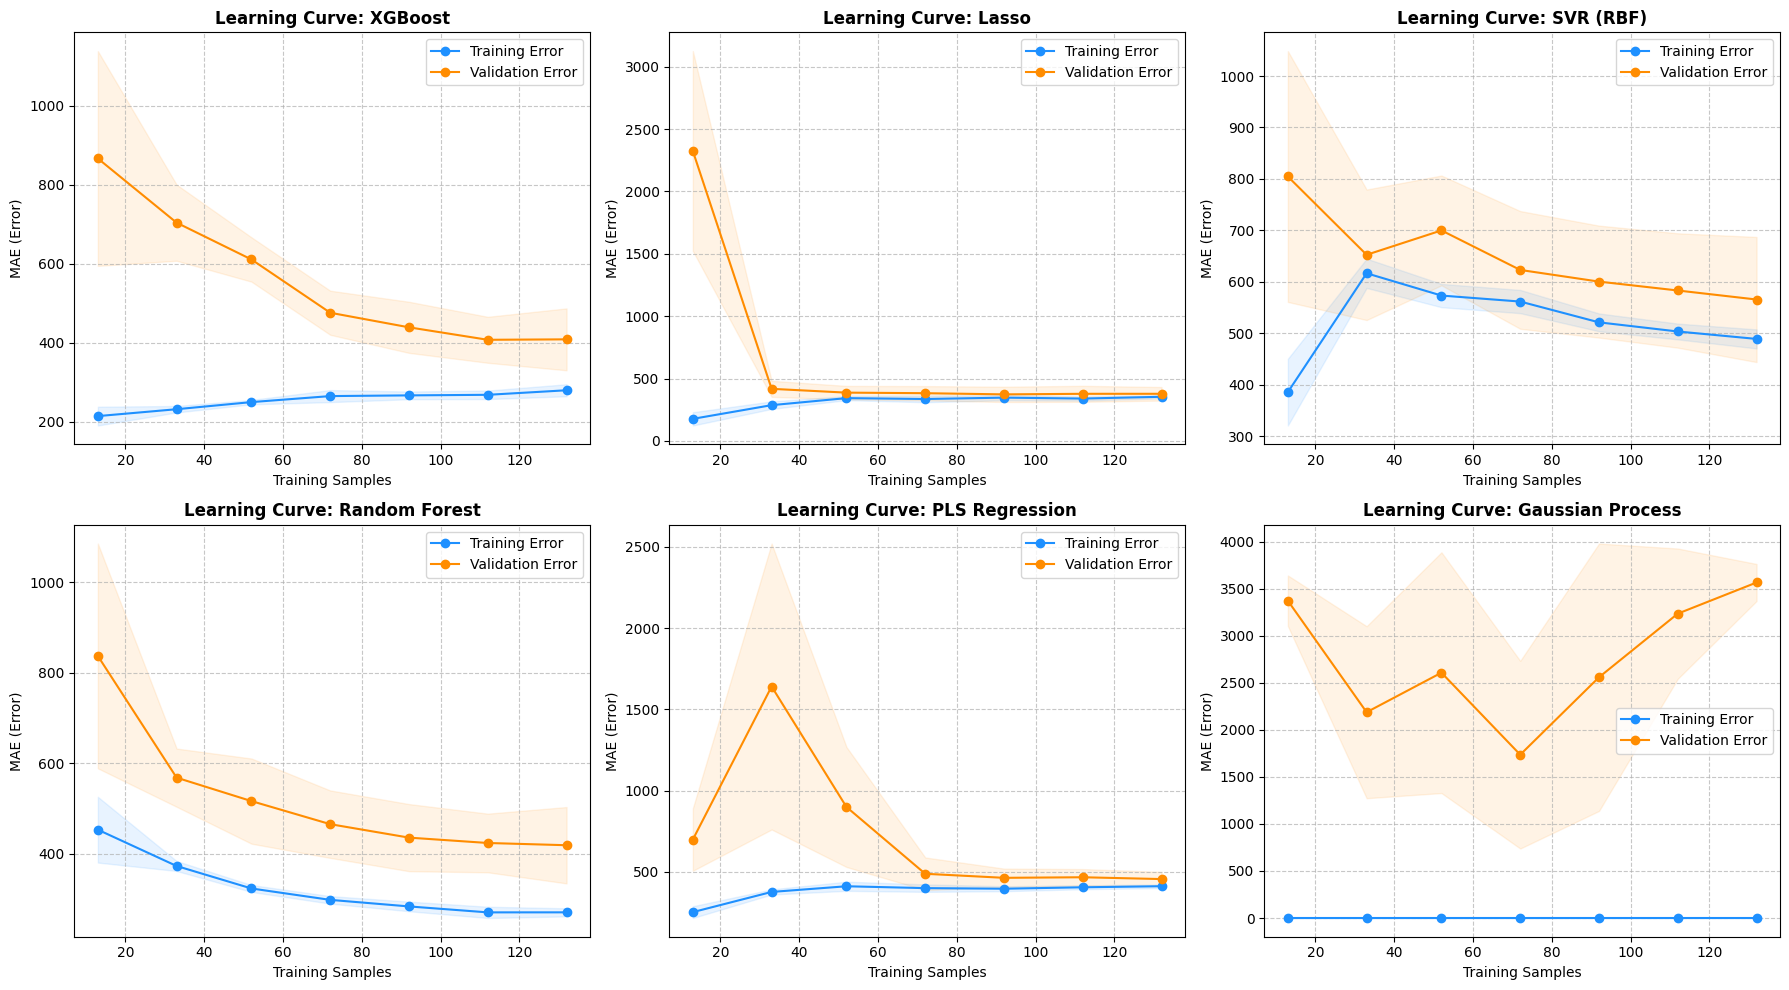

In [11]:
# --- 5. DRAWING LEARNING CURVES ---
print("\n📈 Generating Learning Curves...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    # We use 5-fold CV for the curves to see the variance
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_scaled, y, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 7),
        scoring='neg_mean_absolute_error'
    )
    
    # Convert negative MAE to positive for easier reading
    train_mean = -np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = -np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    # Plotting
    axes[i].plot(train_sizes, train_mean, 'o-', color="dodgerblue", label="Training Error")
    axes[i].plot(train_sizes, test_mean, 'o-', color="darkorange", label="Validation Error")
    axes[i].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="dodgerblue")
    axes[i].fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="darkorange")
    
    axes[i].set_title(f"Learning Curve: {name}", fontweight='bold')
    axes[i].set_xlabel("Training Samples")
    axes[i].set_ylabel("MAE (Error)")
    axes[i].legend(loc="best")
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [12]:
# --- 6. AUTOMATIC WINNER SELECTION ---
winner = results_df.iloc[0]
print(f"\n🏆 FINAL VERDICT: {winner['Model']} is the most production-ready.")
print(f"It achieved {winner['Accuracy (%)']:.2f}% Accuracy with an Overfit Gap of {winner['Overfit Gap']:.4f}.")


🏆 FINAL VERDICT: Lasso is the most production-ready.
It achieved 88.65% Accuracy with an Overfit Gap of 0.0591.


# Best model

🔍 Running Leave-One-Out Cross-Validation...
📊 Training R2 Check: 0.7588 (Ideal: 0.70 - 0.85)


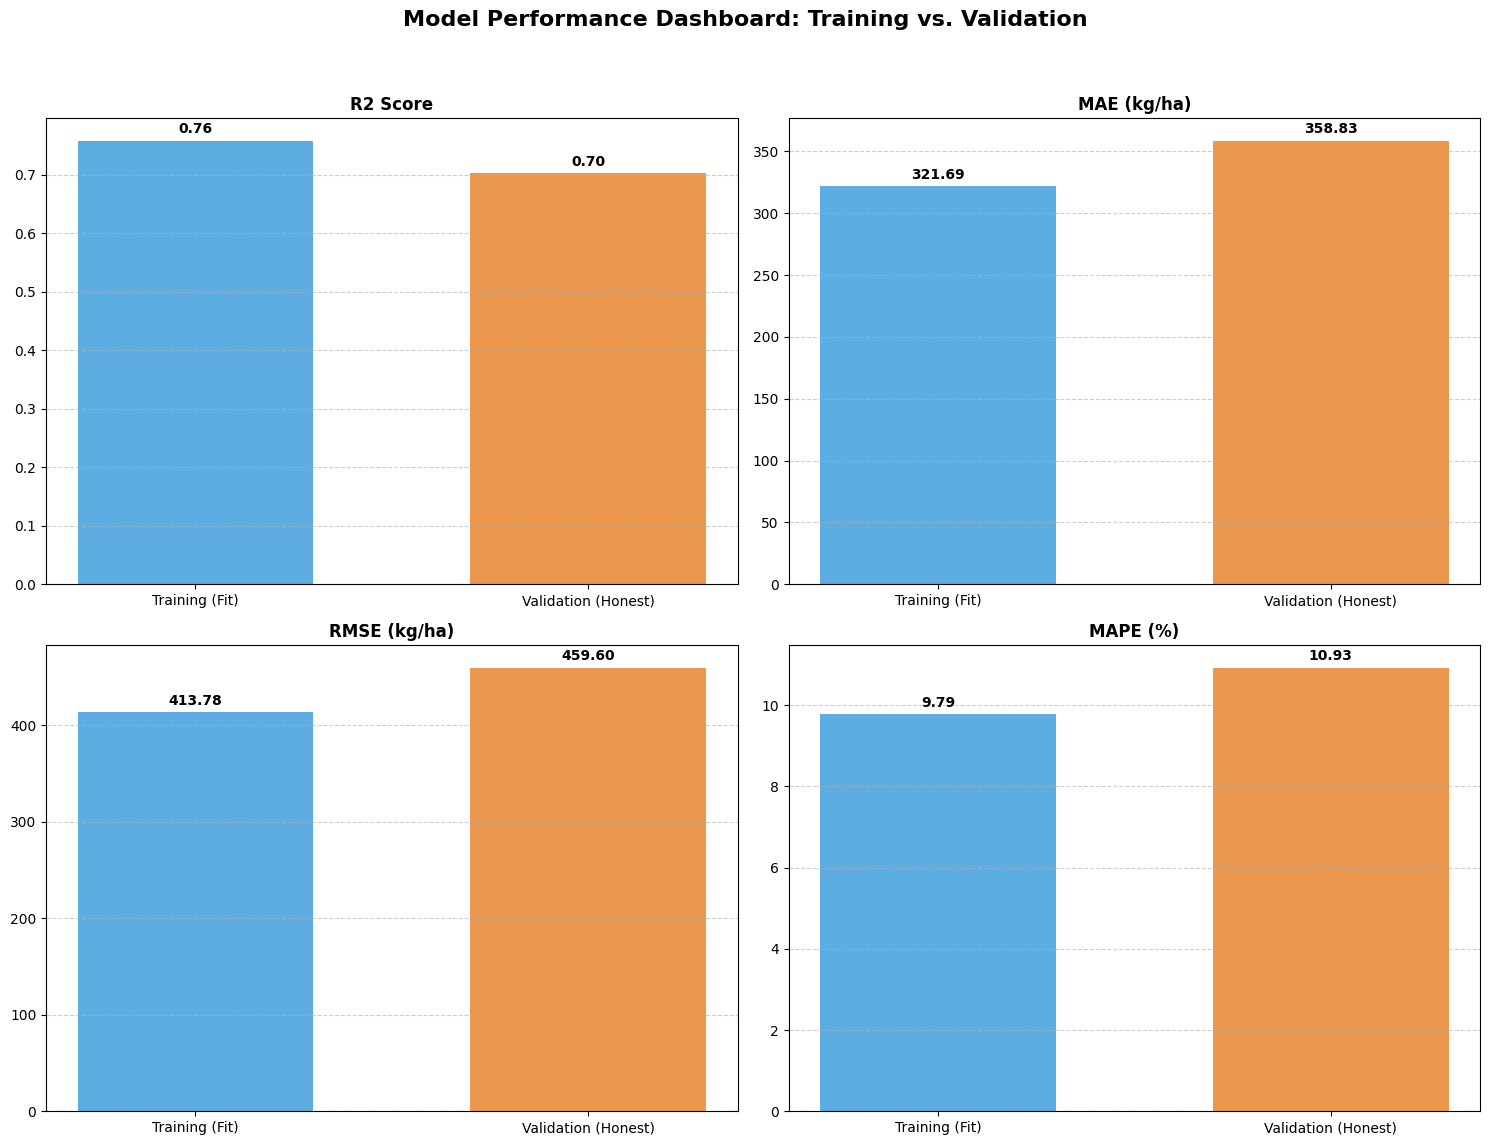

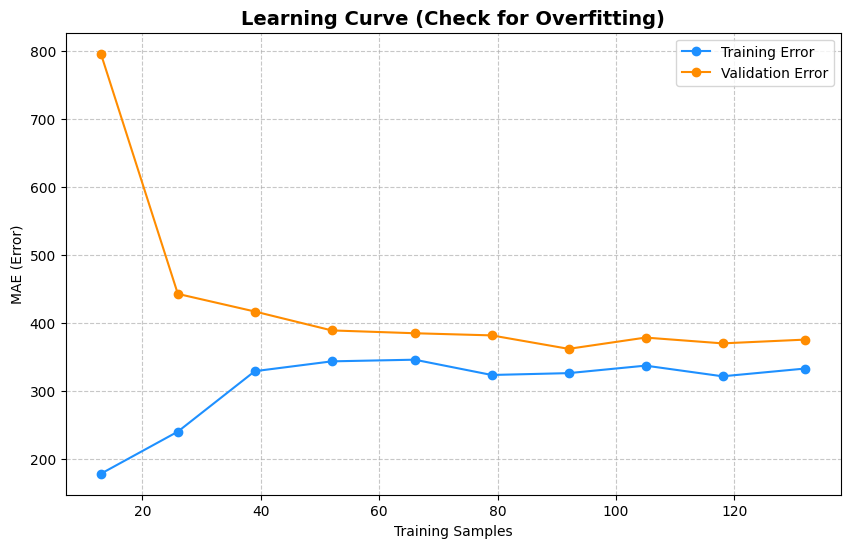


✅ Final Honest Accuracy (100-MAPE): 89.07%
✅ Generalization Gap (R2): 0.0564
💾 Model and Scaler saved successfully.


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import LeaveOneOut, cross_val_predict, learning_curve
from sklearn.metrics import (
    r2_score, 
    mean_absolute_error, 
    mean_squared_error, 
    mean_absolute_percentage_error
)

# --- 1. PREPARE DATA ---
X = df_final[features]
y = df_final[target]

# --- 2. SCALE THE FEATURES ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# --- 3. DEFINE THE MODEL (LASSO CV) ---
# Note: Fixed variable name to 'yield_model' for consistency
yield_model = LassoCV(
    alphas=np.logspace(-2, 2, 100), 
    cv=5, 
    max_iter=10000, 
    selection='random', 
    random_state=42,
    n_jobs=-1
)

# --- 4. EVALUATE (Honest Validation via LOOCV) ---
print("🔍 Running Leave-One-Out Cross-Validation...")
loo = LeaveOneOut()
# Using the defined yield_model here
y_pred_cv = cross_val_predict(yield_model, X_scaled_df, y, cv=loo, n_jobs=-1)

# --- 5. TRAIN ON FULL DATA & CHECK FOR MEMORIZATION ---
yield_model.fit(X_scaled_df, y)
y_pred_train = yield_model.predict(X_scaled_df)

# Check if Training R2 is suspiciously 1.0 (memorization)
train_r2_val = yield_model.score(X_scaled_df, y)
print(f"📊 Training R2 Check: {train_r2_val:.4f} (Ideal: 0.70 - 0.85)")

# --- 6. CALCULATE METRICS ---
def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return [r2, mae, rmse, mape]

train_metrics = get_metrics(y, y_pred_train)
val_metrics = get_metrics(y, y_pred_cv)

# --- 7. PLOT 1: PERFORMANCE DASHBOARD ---
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance Dashboard: Training vs. Validation', fontsize=16, fontweight='bold')

metrics_labels = ['R2 Score', 'MAE (kg/ha)', 'RMSE (kg/ha)', 'MAPE (%)']
labels = ['Training (Fit)', 'Validation (Honest)']
colors = ['#3498db', '#e67e22']

for i, ax in enumerate(axes.flatten()):
    vals = [train_metrics[i], val_metrics[i]]
    bars = ax.bar(labels, vals, color=colors, alpha=0.8, width=0.6)
    ax.set_title(metrics_labels[i], fontweight='bold')
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + (height*0.01),
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- 8. PLOT 2: LEARNING CURVE ---
plt.figure(figsize=(10, 6))
train_sizes, train_scores, test_scores = learning_curve(
    yield_model, X_scaled_df, y, cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_mean_absolute_error'
)

train_mean = -np.mean(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, 'o-', color="dodgerblue", label="Training Error")
plt.plot(train_sizes, test_mean, 'o-', color="darkorange", label="Validation Error")
plt.title("Learning Curve (Check for Overfitting)", fontsize=14, fontweight='bold')
plt.xlabel("Training Samples")
plt.ylabel("MAE (Error)")
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- 9. SAVE & REPORT ---
joblib.dump(yield_model, 'rice_yield_model_final.pkl')
joblib.dump(scaler, 'yield_scaler.pkl')

print(f"\n✅ Final Honest Accuracy (100-MAPE): {100 - val_metrics[3]:.2f}%")
print(f"✅ Generalization Gap (R2): {train_metrics[0] - val_metrics[0]:.4f}")
print("💾 Model and Scaler saved successfully.")